# **R: Experiment - 2**

Mohd Talha Patrawala

CMPN - B

23102B0025

In [54]:
required_pkgs <- c("microbenchmark", "naniar", "skimr", "dplyr", "ggplot2")
new_pkgs <- required_pkgs[!(required_pkgs %in% installed.packages()[, "Package"])]
if (length(new_pkgs) > 0) install.packages(new_pkgs)

library(microbenchmark)
library(naniar)
library(skimr)
library(dplyr)
library(ggplot2)

set.seed(42)

# **Lab 3**

In [55]:
heart_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

heart_col_names <- c("age","sex","cp","trestbps","chol","fbs","restecg",
                      "thalach","exang","oldpeak","slope","ca","thal","target")

heart <- tryCatch({
  read.csv(heart_url, header = FALSE, na.strings = "?", col.names = heart_col_names)
}, error = function(e) {
  message("Could not download Heart Disease dataset (", conditionMessage(e),
          "). Generating a synthetic sample of the same structure instead.")
  n <- 300
  data.frame(
    age      = sample(29:77, n, replace = TRUE),
    sex      = sample(0:1, n, replace = TRUE),
    cp       = sample(0:3, n, replace = TRUE),
    trestbps = round(rnorm(n, mean = 131, sd = 17)),
    chol     = round(rnorm(n, mean = 246, sd = 52)),
    fbs      = sample(0:1, n, replace = TRUE),
    restecg  = sample(0:2, n, replace = TRUE),
    thalach  = round(rnorm(n, mean = 150, sd = 23)),
    exang    = sample(0:1, n, replace = TRUE),
    oldpeak  = round(runif(n, 0, 6), 1),
    slope    = sample(0:2, n, replace = TRUE),
    ca       = sample(0:3, n, replace = TRUE),
    thal     = sample(c(3, 6, 7), n, replace = TRUE),
    target   = sample(0:1, n, replace = TRUE)
  )
})

cat("Rows loaded:", nrow(heart), "\n")

Rows loaded: 303 


In [56]:
n <- nrow(heart)

neg_idx <- sample(1:n, 5)
heart$trestbps[neg_idx] <- -abs(heart$trestbps[neg_idx])

na_idx <- sample(setdiff(1:n, neg_idx), 8)
heart$trestbps[na_idx] <- NA

extreme_idx <- sample(setdiff(1:n, c(neg_idx, na_idx)), 5)
heart$trestbps[extreme_idx] <- sample(305:400, 5)

cat("Injected -> negative:", length(neg_idx),
    "| missing:", length(na_idx),
    "| extreme:", length(extreme_idx), "\n")

Injected -> negative: 5 | missing: 8 | extreme: 5 


In [57]:
clean_bp_value <- function(x) {
  if (is.na(x)) {
    return(NA_real_)
  } else if (x < 0) {
    return(NA_real_)
  } else if (x > 250) {
    return(250)
  } else {
    return(x)
  }
}

heart$trestbps_clean_loop <- sapply(heart$trestbps, clean_bp_value)

cat("\nSample raw vs cleaned BP:\n")
print(head(data.frame(raw = heart$trestbps,
                       cleaned = heart$trestbps_clean_loop), 10))


Sample raw vs cleaned BP:
   raw cleaned
1  145     145
2  160     160
3  120     120
4  130     130
5  362     250
6  120     120
7  140     140
8  120     120
9  130     130
10 140     140


In [58]:
safe_mean_bp <- function(bp_vector) {
  tryCatch({
    m <- mean(bp_vector, na.rm = TRUE)
    if (is.nan(m)) {
      warning("All BP values are missing; mean cannot be computed.")
      return(NA_real_)
    }
    return(m)
  }, warning = function(w) {
    message("Warning while computing mean BP: ", conditionMessage(w))
    return(NA_real_)
  }, error = function(e) {
    message("Error while computing mean BP: ", conditionMessage(e))
    return(NA_real_)
  })
}

mean_bp <- safe_mean_bp(heart$trestbps_clean_loop)
cat("\nSafe mean BP (missing ignored):", round(mean_bp, 2), "\n")

safe_ratio <- function(numerator, denominator) {
  tryCatch({
    if (is.na(numerator) || is.na(denominator)) stop("Numerator or denominator is NA")
    if (denominator == 0) stop("Denominator is zero")
    if (!is.numeric(numerator) || !is.numeric(denominator)) stop("Non-numeric input supplied")
    return(numerator / denominator)
  }, error = function(e) {
    message("Ratio could not be computed (", conditionMessage(e), "). Returning NA.")
    return(NA_real_)
  })
}

heart$chol_bp_ratio <- mapply(safe_ratio, heart$chol, heart$trestbps_clean_loop)

cat("\nSample chol/trestbps ratios:\n")
print(head(data.frame(chol = heart$chol,
                       trestbps = heart$trestbps_clean_loop,
                       ratio = round(heart$chol_bp_ratio, 3)), 8))

cat("\nDemo -> ratio with denominator = 0:", safe_ratio(200, 0), "\n")
cat("Demo -> ratio with NA denominator :", safe_ratio(200, NA), "\n")


Safe mean BP (missing ignored): 133.99 


Ratio could not be computed (Numerator or denominator is NA). Returning NA.

Ratio could not be computed (Numerator or denominator is NA). Returning NA.

Ratio could not be computed (Numerator or denominator is NA). Returning NA.

Ratio could not be computed (Numerator or denominator is NA). Returning NA.

Ratio could not be computed (Numerator or denominator is NA). Returning NA.

Ratio could not be computed (Numerator or denominator is NA). Returning NA.

Ratio could not be computed (Numerator or denominator is NA). Returning NA.

Ratio could not be computed (Numerator or denominator is NA). Returning NA.

Ratio could not be computed (Numerator or denominator is NA). Returning NA.

Ratio could not be computed (Numerator or denominator is NA). Returning NA.

Ratio could not be computed (Numerator or denominator is NA). Returning NA.

Ratio could not be computed (Numerator or denominator is NA). Returning NA.

Ratio could not be computed (Numerator or denominator is NA). Returning NA.



Sample chol/trestbps ratios:
  chol trestbps ratio
1  233      145 1.607
2  286      160 1.788
3  229      120 1.908
4  250      130 1.923
5  204      250 0.816
6  236      120 1.967
7  268      140 1.914
8  354      120 2.950


Ratio could not be computed (Denominator is zero). Returning NA.




Demo -> ratio with denominator = 0: NA 


Ratio could not be computed (Numerator or denominator is NA). Returning NA.



Demo -> ratio with NA denominator : NA 


In [59]:
raw_bp <- heart$trestbps

loop_clean <- function(bp_vector) {
  result <- numeric(length(bp_vector))
  for (i in seq_along(bp_vector)) {
    val <- bp_vector[i]
    if (is.na(val)) {
      result[i] <- NA_real_
    } else if (val < 0) {
      result[i] <- NA_real_
    } else if (val > 250) {
      result[i] <- 250
    } else {
      result[i] <- val
    }
  }
  return(result)
}

vectorized_clean <- function(bp_vector) {
  out <- bp_vector
  out[!is.na(out) & out < 0]   <- NA_real_
  out[!is.na(out) & out > 250] <- 250
  return(out)
}

loop_result       <- loop_clean(raw_bp)
vectorized_result <- vectorized_clean(raw_bp)
cat("\nLoop & vectorized results identical:",
    all(loop_result == vectorized_result | (is.na(loop_result) & is.na(vectorized_result))), "\n")

cat("\n-- system.time(): loop-based --\n")
print(system.time(loop_clean(raw_bp)))

cat("\n-- system.time(): vectorized --\n")
print(system.time(vectorized_clean(raw_bp)))

bench <- microbenchmark(
  loop       = loop_clean(raw_bp),
  vectorized = vectorized_clean(raw_bp),
  times = 100
)
cat("\n-- microbenchmark (100 reps) --\n")
print(bench)

heart$trestbps_clean <- vectorized_result


Loop & vectorized results identical: TRUE 

-- system.time(): loop-based --
   user  system elapsed 
      0       0       0 

-- system.time(): vectorized --
   user  system elapsed 
      0       0       0 

-- microbenchmark (100 reps) --
Unit: microseconds
       expr    min      lq      mean   median       uq     max neval
       loop 90.859 94.4790 123.93069 103.0195 116.1970 666.037   100
 vectorized 10.382 12.2325  18.81664  13.8700  16.7135 167.313   100


In [60]:
n_missing <- sum(is.na(heart$trestbps_clean))
bp_valid  <- heart$trestbps_clean[!is.na(heart$trestbps_clean)]

cat("\n---- Validation (cleaned trestbps) ----\n")
cat("Missing BP values      :", n_missing, "\n")
cat("Minimum BP              :", min(bp_valid), "\n")
cat("Maximum BP              :", max(bp_valid), "\n")
cat("Mean BP                 :", round(mean(bp_valid), 2), "\n")
cat("Median BP               :", median(bp_valid), "\n")
cat("Any negative values left:", any(bp_valid < 0), "\n")
cat("Any values > 250 left   :", any(bp_valid > 250), "\n")


---- Validation (cleaned trestbps) ----
Missing BP values      : 13 
Minimum BP              : 94 
Maximum BP              : 250 
Mean BP                 : 133.99 
Median BP               : 130 
Any negative values left: FALSE 
Any values > 250 left   : FALSE 


In [61]:
heart_out <- heart
heart_out$trestbps <- heart_out$trestbps_clean
heart_out$trestbps_clean_loop <- NULL
heart_out$trestbps_clean <- NULL

write.csv(heart_out, "cleaned_heart_data.csv", row.names = FALSE)
cat("\nSaved -> cleaned_heart_data.csv\n")


Saved -> cleaned_heart_data.csv




---


# LAB 3 CONCLUSION:

 Loop-based and vectorized cleaning produce identical results, but
 system.time() and microbenchmark both show the vectorized approach
 is consistently faster, since it runs in optimized low-level C code
 over the whole vector at once instead of iterating in the R
 interpreter. Vectorized operations should be preferred for cleaning
 tasks like this, especially as dataset size grows.


---





---


# **Lab 4**



---



In [62]:
adult_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

adult_col_names <- c("age","workclass","fnlwgt","education","education_num",
                      "marital_status","occupation","relationship","race","sex",
                      "capital_gain","capital_loss","hours_per_week",
                      "native_country","income")

adult <- tryCatch({
  read.csv(adult_url, header = FALSE, col.names = adult_col_names,
            na.strings = "?", strip.white = TRUE, stringsAsFactors = FALSE)
}, error = function(e) {
  message("Could not download Adult dataset (", conditionMessage(e),
          "). Generating a synthetic sample of the same structure instead.")
  n <- 500
  data.frame(
    age            = sample(17:75, n, replace = TRUE),
    workclass      = sample(c("Private","Self-emp","Government","Without-pay"), n, replace = TRUE),
    fnlwgt         = sample(50000:400000, n, replace = TRUE),
    education      = sample(c("Bachelors","HS-grad","Masters","Some-college","Doctorate"), n, replace = TRUE),
    education_num  = sample(1:16, n, replace = TRUE),
    marital_status = sample(c("Married","Never-married","Divorced","Widowed"), n, replace = TRUE),
    occupation     = sample(c("Tech-support","Sales","Exec-managerial","Craft-repair","Other-service"), n, replace = TRUE),
    relationship   = sample(c("Husband","Wife","Not-in-family","Own-child"), n, replace = TRUE),
    race           = sample(c("White","Black","Asian-Pac-Islander","Other"), n, replace = TRUE),
    sex            = sample(c("Male","Female"), n, replace = TRUE),
    capital_gain   = sample(0:20000, n, replace = TRUE),
    capital_loss   = sample(0:2000, n, replace = TRUE),
    hours_per_week = round(rnorm(n, mean = 40, sd = 10)),
    native_country = sample(c("United-States","Mexico","India","Germany","Other"), n, replace = TRUE),
    income         = sample(c("<=50K", ">50K"), n, replace = TRUE),
    stringsAsFactors = FALSE
  )
})

cat("Rows loaded:", nrow(adult), "\n")

Rows loaded: 32561 


In [63]:
n <- nrow(adult)

na_idx <- sample(1:n, 10)
adult$hours_per_week[na_idx] <- NA

blank_idx <- sample(setdiff(1:n, na_idx), 8)
adult$workclass[blank_idx] <- ""

nan_idx <- sample(setdiff(1:n, c(na_idx, blank_idx)), 6)
adult$capital_gain[nan_idx] <- 0 / 0   # NaN

impossible_idx <- sample(setdiff(1:n, c(na_idx, blank_idx, nan_idx)), 5)
adult$age[impossible_idx] <- 999

cat("Injected -> NA:", length(na_idx),
    "| blank strings:", length(blank_idx),
    "| NaN:", length(nan_idx),
    "| impossible age=999:", length(impossible_idx), "\n")

Injected -> NA: 10 | blank strings: 8 | NaN: 6 | impossible age=999: 5 


In [64]:
cat("\n---- NA detection (hours_per_week) ----\n")
cat("Count of NA:", sum(is.na(adult$hours_per_week)), "\n")

cat("\n---- NaN detection (capital_gain) ----\n")
cat("Count of NaN:", sum(is.nan(adult$capital_gain)), "\n")

cat("\n---- is.null() demonstration ----\n")
x <- NULL
cat("is.null(x) for a NULL object            :", is.null(x), "\n")
cat("is.null(adult$workclass[1]) for a cell  :", is.null(adult$workclass[1]), "\n")
cat("NOTE: NULL represents the absence of an R object, not a value inside\n",
    "a vector/column. A data-frame cell always holds *something* -- even\n",
    "'missing' is represented as NA, not NULL -- which is why is.null()\n",
    "on a cell is always FALSE.\n")

cat("\n---- Blank string detection (workclass) ----\n")
cat("Count of blank strings:", sum(adult$workclass == "", na.rm = TRUE), "\n")

cat("\n---- Impossible value detection (age == 999) ----\n")
cat("Count of impossible ages:", sum(adult$age == 999, na.rm = TRUE), "\n")

cat("\n---- Variable-wise missing summary (naniar) ----\n")
print(miss_var_summary(adult))



---- NA detection (hours_per_week) ----
Count of NA: 10 

---- NaN detection (capital_gain) ----
Count of NaN: 6 

---- is.null() demonstration ----
is.null(x) for a NULL object            : TRUE 
is.null(adult$workclass[1]) for a cell  : FALSE 
NOTE: NULL represents the absence of an R object, not a value inside
 a vector/column. A data-frame cell always holds *something* -- even
 'missing' is represented as NA, not NULL -- which is why is.null()
 on a cell is always FALSE.

---- Blank string detection (workclass) ----
Count of blank strings: 8 

---- Impossible value detection (age == 999) ----
Count of impossible ages: 5 

---- Variable-wise missing summary (naniar) ----
# A tibble: 15 × 3
   variable       n_miss pct_miss
   <chr>           <int>    <num>
 1 occupation       1843   5.66  
 2 workclass        1836   5.64  
 3 native_country    583   1.79  
 4 hours_per_week     10   0.0307
 5 capital_gain        6   0.0184
 6 age                 0   0     
 7 fnlwgt              0 

In [65]:
adult_clean <- adult

adult_clean$age[adult_clean$age == 999] <- NA

adult_clean$workclass[adult_clean$workclass == ""] <- "Unknown"

median_hours <- median(adult_clean$hours_per_week, na.rm = TRUE)
adult_clean$hours_per_week[is.na(adult_clean$hours_per_week)] <- median_hours

nan_rows_before <- sum(is.nan(adult_clean$capital_gain))
adult_clean <- adult_clean[!is.nan(adult_clean$capital_gain), ]
cat("\nRemoved", nan_rows_before, "rows with unrecoverable NaN (capital_gain)\n")

median_age <- median(adult_clean$age, na.rm = TRUE)
adult_clean$age[is.na(adult_clean$age)] <- median_age

categorical_cols <- names(adult_clean)[sapply(adult_clean, is.character)]
for (col in categorical_cols) {
  adult_clean[[col]][is.na(adult_clean[[col]]) | adult_clean[[col]] == ""] <- "Unknown"
}

numeric_cols <- names(adult_clean)[sapply(adult_clean, is.numeric)]
for (col in numeric_cols) {
  if (any(is.na(adult_clean[[col]]))) {
    adult_clean[[col]][is.na(adult_clean[[col]])] <- median(adult_clean[[col]], na.rm = TRUE)
  }
}

complete_mask <- complete.cases(adult_clean)
cat("Complete observations   :", sum(complete_mask), "\n")
cat("Incomplete observations :", sum(!complete_mask), "\n")


Removed 6 rows with unrecoverable NaN (capital_gain)
Complete observations   : 32555 
Incomplete observations : 0 


In [66]:
impute_median <- function(x) {
  missing_mask <- is.na(x)
  med <- median(x[!missing_mask])
  x[missing_mask] <- med
  return(x)
}

demo_vec <- adult_clean$capital_loss
demo_vec[c(3, 10)] <- NA
cat("\nDemo before custom imputation:", head(demo_vec, 12), "\n")
demo_vec_imputed <- impute_median(demo_vec)
cat("Demo after custom imputation :", head(demo_vec_imputed, 12), "\n")

adult_clean$capital_loss <- impute_median(adult_clean$capital_loss)


Demo before custom imputation: 0 0 NA 0 0 0 0 0 0 NA 0 0 
Demo after custom imputation : 0 0 0 0 0 0 0 0 0 0 0 0 



---- % missing BEFORE cleaning ----
           age      workclass         fnlwgt      education  education_num 
          0.00           5.64           0.00           0.00           0.00 
marital_status     occupation   relationship           race            sex 
          0.00           5.66           0.00           0.00           0.00 
  capital_gain   capital_loss hours_per_week native_country         income 
          0.02           0.00           0.03           1.79           0.00 

---- % missing AFTER cleaning ----
           age      workclass         fnlwgt      education  education_num 
             0              0              0              0              0 
marital_status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              0              0              0 


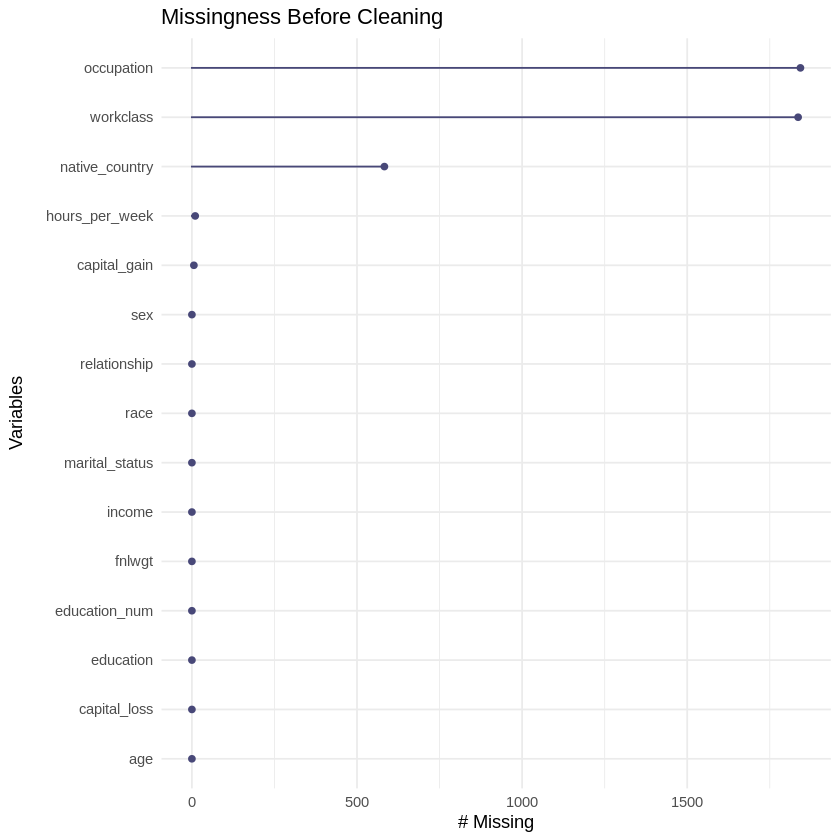

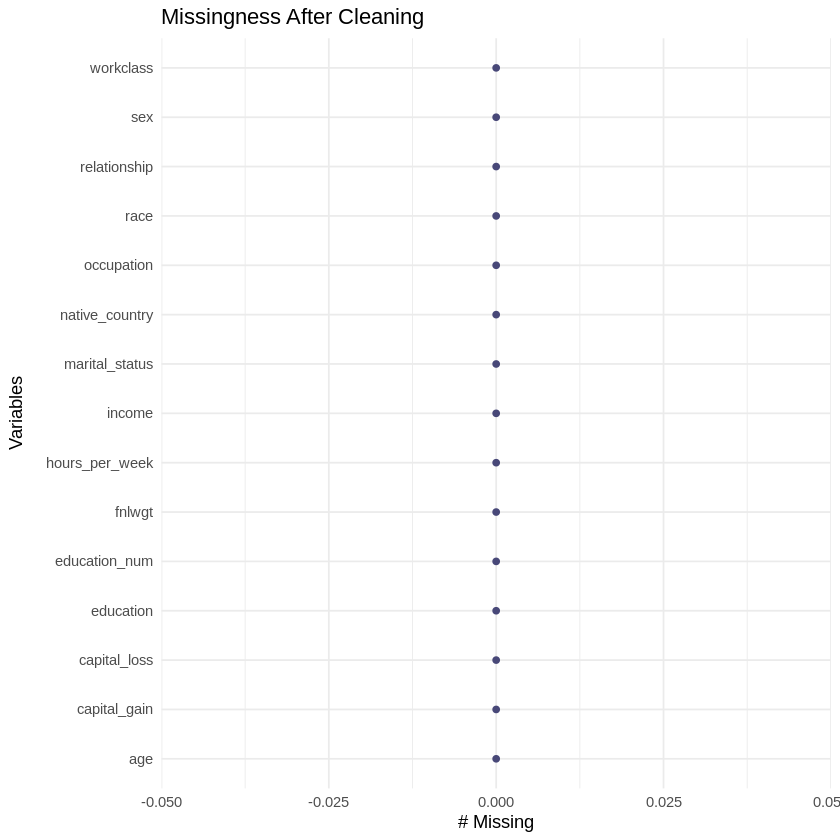

In [67]:
pct_missing <- function(df) {
  sapply(df, function(col) round(100 * sum(is.na(col)) / length(col), 2))
}

cat("\n---- % missing BEFORE cleaning ----\n")
print(pct_missing(adult))

cat("\n---- % missing AFTER cleaning ----\n")
print(pct_missing(adult_clean))

vis_before <- gg_miss_var(adult) + ggtitle("Missingness Before Cleaning")
print(vis_before)

vis_after <- gg_miss_var(adult_clean) + ggtitle("Missingness After Cleaning")
print(vis_after)


In [68]:
cat("\n---- skimr::skim() summary of cleaned data ----\n")
print(skim(adult_clean))

cat("\nAny age == 999 remaining :", any(adult_clean$age == 999), "\n")
cat("Any NA in hours_per_week :", any(is.na(adult_clean$hours_per_week)), "\n")
cat("Any NA in age            :", any(is.na(adult_clean$age)), "\n")
cat("Any blank workclass left :", any(adult_clean$workclass == ""), "\n")


---- skimr::skim() summary of cleaned data ----
── Data Summary ────────────────────────
                           Values     
Name                       adult_clean
Number of rows             32555      
Number of columns          15         
_______________________               
Column type frequency:                
  character                9          
  numeric                  6          
________________________              
Group variables            None       

── Variable type: character ────────────────────────────────────────────────────
  skim_variable  n_missing complete_rate min max empty n_unique whitespace
1 workclass              0             1   7  16     0        9          0
2 education              0             1   3  12     0       16          0
3 marital_status         0             1   7  21     0        7          0
4 occupation             0             1   5  17     0       15          0
5 relationship           0             1   4  14     0        6

In [69]:
write.csv(adult_clean, "cleaned_adult_data.csv", row.names = FALSE)
cat("\nSaved -> cleaned_adult_data.csv\n")


Saved -> cleaned_adult_data.csv




---


# LAB 4 INTERPRETATION:

 The dataset contained four distinct problem types -- ordinary NA,
 NaN from invalid arithmetic, blank-string placeholders, and
 semantically impossible values (age = 999) -- each requiring its own
 detection logic (is.na, is.nan, == "", range checks) and its own
 treatment (median imputation, 'Unknown' recoding, row removal, or
 NA-conversion + imputation). After treatment, missingness in every
 affected column dropped to 0%, confirmed by skimr::skim().